 $$L(w, b) = \frac{1}{2n} \sum_{i=1}^n (y_i - X_i w - b)^2 + \alpha \cdot \left( \rho \|w\|_1 + \frac{1 - \rho}{2} \|w\|_2^2 \right)$$

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

In [56]:
X, y = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)
X = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(10)])
y = pd.Series(y, name="target")

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
from sklearn.linear_model import ElasticNetCV
enet = ElasticNetCV(cv=5).fit(X_train_scaled, y_train)
print(f"Best alpha: {enet.alpha_}, Best l1_ratio: {enet.l1_ratio_}")

Best alpha: 0.1743653149646364, Best l1_ratio: 0.5


In [59]:
y_pred = enet.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R^2 score: {r2:.2f}, Mean Squared Error: {mse:.2f}")

R^2 score: 0.99, Mean Squared Error: 146.27


In [60]:
enet.coef_

array([36.84547157, 57.51106767, 18.24858199, 42.60546483, 22.56724964,
       14.84414987, 77.93533784, 61.53198128,  6.68197453, 25.01222765])

Text(0, 0.5, 'Feature')

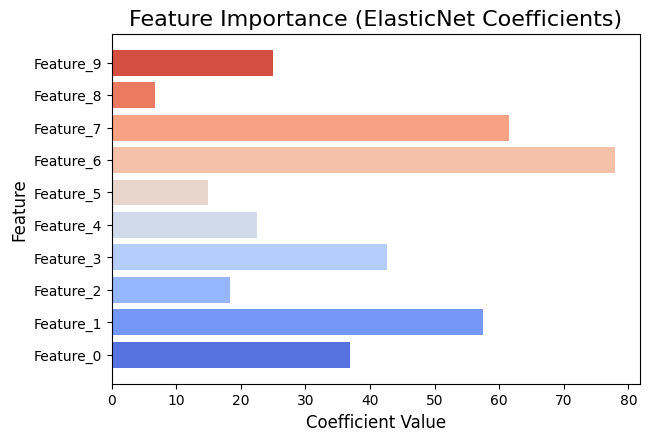

In [61]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
coef = enet.coef_
colors = sns.color_palette("coolwarm", len(coef))
plt.barh(X.columns, coef, color=colors)
plt.title('Feature Importance (ElasticNet Coefficients)', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)

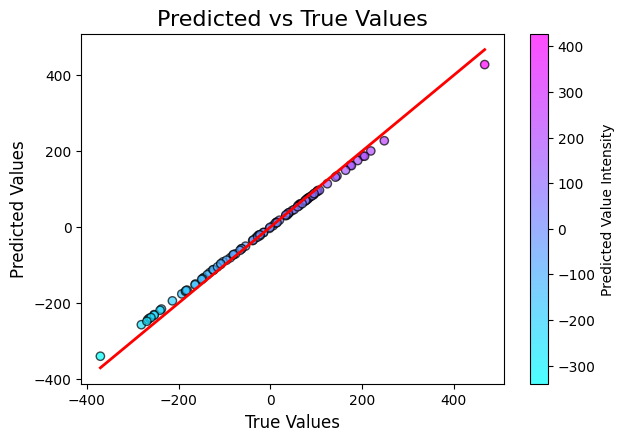

In [62]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred, alpha=.7, c=y_pred, cmap='cool', edgecolor='k')  # 按数值染色
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.title('Predicted vs True Values', fontsize=16)
plt.xlabel('True Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.colorbar(label="Predicted Value Intensity")

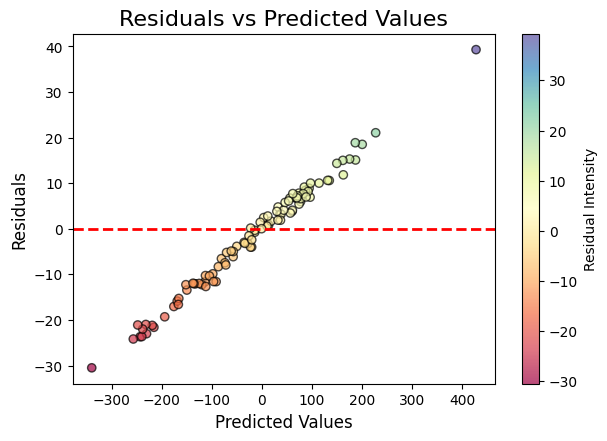

In [63]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 3)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, c=residuals, cmap='Spectral', alpha=0.7, edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted Values', fontsize=16)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.colorbar(label="Residual Intensity")

Text(0, 0.5, 'Score / Error')

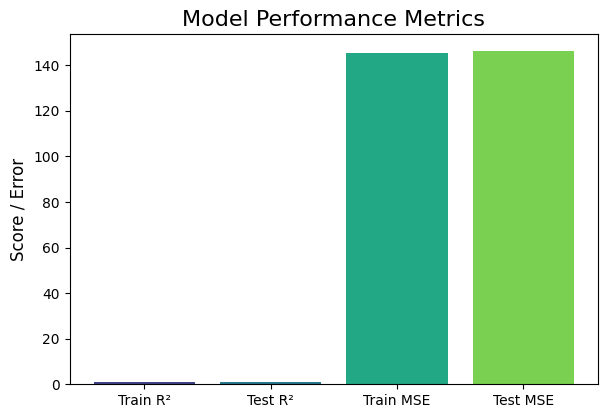

In [64]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 4)
metrics = ['Train R²', 'Test R²', 'Train MSE', 'Test MSE']
r2_train = r2_score(y_train, enet.predict(X_train_scaled))
mse_train = mean_squared_error(y_train, enet.predict(X_train_scaled))
values = [r2_train, r2, mse_train, mse]
colors = sns.color_palette("viridis", len(metrics))
plt.bar(metrics, values, color=colors)
plt.title('Model Performance Metrics', fontsize=16)
plt.ylabel('Score / Error', fontsize=12)

### StandardScaler在树模型,特征同量纲时不用,其余均需要